### 基于K-Means聚类与Prophet时序预测的重庆上市车企财务智能预警研究
#### ——赛力斯外部协同经营模式对标长安自主研发模式
##### 一、数据获取与预处理

1. 数据获取

（1）获取财务报表数据：2016年Q1-2025年Q4
* `data/collect_financial_data.py` # 获取财务数据
* 获取8家对标车企（赛力斯★/长安汽车★/比亚迪/上汽集团/长城汽车/广汽集团/江淮汽车/北汽蓝谷）的资产负债表、利润表和现金流量表的年度数据，并保存为excel文件。
  
（2）获取车企销售数据：2023年Q1-2026年Q4
* `data/add_company_sales.py` # 添加公司销售数据
* `data/extract_sales_structure.py` # 获取销售结构数据

2. 数据预处理

（1）数据读取   

In [12]:
import pandas as pd
from pathlib import Path

data_dir = Path('data')
all_data = {
    file.stem.replace('_财务数据', ''): pd.read_excel(file)
    for file in data_dir.glob('*_财务数据.xlsx')
}
# 加载
for company, df in all_data.items():
    print(f"{company}: {len(df)} 条记录")
list(all_data.values())[0].head() # 预览

000625_长安汽车: 69 条记录
002594_比亚迪: 64 条记录
600104_上汽集团: 69 条记录
600418_江淮汽车: 61 条记录
600733_北汽蓝谷: 61 条记录
601127_赛力斯: 63 条记录
601238_广汽集团: 69 条记录
601633_长城汽车: 65 条记录


,Unnamed: 0,2016年报,2016Q1,2016Q2,2016Q3,2017年报,2017Q1,2017Q2,2017Q3,2018年报,...,2023Q2,2023Q3,2024年报,2024Q1,2024Q2,2024Q3,2025年报,2025Q1,2025Q2,2025Q3
0,货币资金,2.478300e+10,1.871700e+10,2.135800e+10,2.510300e+10,2.263200e+10,2.832800e+10,2.788200e+10,2.399200e+10,9.981000e+09,...,6.598600e+10,7.219200e+10,6.418200e+10,7.006800e+10,7.093900e+10,7.000500e+10,5.402200e+10,6.012900e+10,5.283000e+10,5.524100e+10
1,交易性金融资产,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.620000e+08,1.570000e+08,1.550000e+08,1.440000e+08,1.530000e+08,1.670000e+08,NaN,1.500000e+08,1.620000e+08,1.024000e+05
2,应收账款,1.499000e+09,1.270000e+09,1.480000e+09,1.518000e+09,1.807000e+09,2.427000e+09,1.900000e+09,1.996000e+09,1.409000e+09,...,2.477000e+09,2.669000e+09,3.398000e+09,3.277000e+09,2.989000e+09,4.226000e+09,4.197000e+09,5.021000e+09,6.628000e+09,7.216000e+09
3,应收票据及应收账款,3.050100e+10,2.414100e+10,2.131300e+10,2.162200e+10,3.096300e+10,2.588000e+10,2.363500e+10,2.336100e+10,2.197100e+10,...,3.644100e+10,3.804700e+10,4.897900e+10,3.698200e+10,3.698500e+10,3.344300e+10,3.719500e+10,4.285000e+10,3.218500e+10,2.773400e+10
4,预付款项,1.061000e+09,6.700000e+08,9.910000e+08,8.800000e+08,1.102000e+09,1.323000e+09,1.274000e+09,1.832000e+09,8.660000e+08,...,6.620000e+08,9.880000e+08,5.070000e+08,4.820000e+08,5.830000e+08,4.560000e+08,4.920000e+08,4.360000e+08,4.000000e+08,7.940000e+08


(2) 报表合并

In [13]:
def integrate_financial_data(company_code):          # 参数是 company_code，不是 name
    file_path = f'data/{company_code}_财务数据.xlsx'
    
    df_balance = pd.read_excel(file_path, sheet_name='资产负债表', index_col=0)
    df_income  = pd.read_excel(file_path, sheet_name='利润表', index_col=0)
    df_cash    = pd.read_excel(file_path, sheet_name='现金流量表', index_col=0)
    
    df_balance = df_balance.T.add_suffix('_资产')
    df_income  = df_income.T.add_suffix('_利润')
    df_cash    = df_cash.T.add_suffix('_现金流')
    
    data = pd.concat([df_income, df_balance, df_cash], axis=1).fillna(0)
    print(f'完成: {len(data)} 期 × {len(data.columns)} 个指标')
    return data  

# 查看
companies = [f.stem.replace('_财务数据','') for f in Path('data').glob('*_财务数据.xlsx')]
print('可用公司:', companies)

data = integrate_financial_data('601127_赛力斯')
data.info()
data.head()
#data.to_csv('data/601127_赛力斯_财务数据_merged.csv', index=True, encoding='utf-8-sig')  # 保存为 CSV 文件

可用公司: ['000625_长安汽车', '002594_比亚迪', '600104_上汽集团', '600418_江淮汽车', '600733_北汽蓝谷', '601127_赛力斯', '601238_广汽集团', '601633_长城汽车']
完成: 40 期 × 154 个指标
<class 'pandas.DataFrame'>
Index: 40 entries, 2016年报 to 2025Q3
Columns: 154 entries, 一、营业总收入_利润 to 间接法-现金及现金等价物净增加额_现金流
dtypes: float64(154)
memory usage: 48.4+ KB


,一、营业总收入_利润,营业收入_利润,税金及附加_利润,销售费用_利润,管理费用_利润,研发费用_利润,财务费用_利润,其中：利息费用_利润,其中：利息收入_利润,投资收益_利润,...,投资损失_现金流,递延所得税资产减少_现金流,递延所得税负债增加_现金流,存货的减少_现金流,经营性应收项目的减少_现金流,经营性应付项目的增加_现金流,间接法-经营活动产生的现金流量净额_现金流,现金的期末余额_现金流,减：现金的期初余额_现金流,间接法-现金及现金等价物净增加额_现金流
2016年报,1.619243e+10,1.619243e+10,5.070655e+08,1.040867e+09,8.576498e+08,0.000000e+00,31223587.42,0.000000e+00,0.000000e+00,17085648.52,...,-17085600.0,-2747300.0,-2803400.0,-398000000.0,-3.166000e+09,3.396000e+09,1.146000e+09,2.354000e+09,7.830000e+08,1.571000e+09
2016Q1,3.192494e+09,3.192494e+09,8.975824e+07,2.354520e+08,1.904555e+08,0.000000e+00,19150137.50,0.000000e+00,0.000000e+00,3113381.63,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2016Q2,6.335556e+09,6.335556e+09,1.679867e+08,4.499726e+08,3.629218e+08,0.000000e+00,39083090.27,0.000000e+00,0.000000e+00,4811555.19,...,-4811600.0,2414900.0,-1409500.0,-94636200.0,-9.450730e+07,2.320000e+08,6.140000e+08,1.813000e+09,7.830000e+08,1.030000e+09
2016Q3,1.020144e+10,1.020144e+10,2.830919e+08,7.015685e+08,5.480660e+08,0.000000e+00,49897945.70,0.000000e+00,0.000000e+00,13988970.02,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2017年报,2.193376e+10,2.193376e+10,6.996699e+08,1.282389e+09,9.138462e+08,4.678123e+08,30211619.41,1.378618e+08,1.179849e+08,14875439.06,...,-14875400.0,-7041700.0,-2344900.0,-242000000.0,-9.310000e+08,1.340000e+08,9.970000e+08,4.366000e+09,2.354000e+09,2.012000e+09


(3) 插到新table

In [14]:
from pathlib import Path
import pandas as pd

def integrate_financial_data(company_code):
    file_path = f'data/{company_code}_财务数据.xlsx'
    df_balance = pd.read_excel(file_path, sheet_name='资产负债表', index_col=0)
    df_income  = pd.read_excel(file_path, sheet_name='利润表', index_col=0)
    df_cash    = pd.read_excel(file_path, sheet_name='现金流量表', index_col=0)
    df_balance = df_balance.T.add_suffix('_资产')
    df_income  = df_income.T.add_suffix('_利润')
    df_cash    = df_cash.T.add_suffix('_现金流')
    return pd.concat([df_income, df_balance, df_cash], axis=1).fillna(0)

# 逐家公司追加合并报表 sheet
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    data = integrate_financial_data(code)
    with pd.ExcelWriter(fp, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        data.to_excel(writer, sheet_name='合并报表', index=True)
    print(f' {code}: 已追加合并报表 ({len(data)}期×{len(data.columns)}指标)')


 000625_长安汽车: 已追加合并报表 (40期×160指标)
 002594_比亚迪: 已追加合并报表 (40期×159指标)
 600104_上汽集团: 已追加合并报表 (40期×167指标)
 600418_江淮汽车: 已追加合并报表 (40期×155指标)
 600733_北汽蓝谷: 已追加合并报表 (40期×149指标)
 601127_赛力斯: 已追加合并报表 (40期×154指标)
 601238_广汽集团: 已追加合并报表 (40期×169指标)
 601633_长城汽车: 已追加合并报表 (40期×160指标)


（4） 静态财务指标
* 盈利能力、营运能力、偿债能力、成长能力

In [15]:
import numpy as np

def financial_ratio(name, data):
    """计算15个财务指标（批量构建，无 PerformanceWarning）"""
    col = {
        '营收': '营业收入_利润', '营成': '营业成本_利润', '营利': '营业利润_利润',
        '净利': '净利润_利润', '归母净利': '归属于母公司所有者的净利润_利润',
        '利息': '其中：利息费用_利润', '存货': '存货_资产', '资产': '资产合计_资产',
        '负债': '负债合计_资产', '货币资金': '货币资金_资产', '应收': '应收账款_资产',
        '流资': '流动资产合计_资产', '流负': '流动负债合计_资产',
        '预付': '预付款项_资产', '权益': '归属于母公司所有者权益合计_资产',
    }
    
    # 所有新列一次性构建，避免 DataFrame 碎片化
    new_cols = {}
    new_cols['息税前利润'] = data[col['营利']] + data[col['利息']]
    new_cols['毛利率'] = 1 - data[col['营成']] / data[col['营收']]
    new_cols['营业利润率'] = data[col['营利']] / data[col['营收']]
    new_cols['净利润率'] = data[col['净利']] / data[col['营收']]
    new_cols['净资产收益率'] = 2 * data[col['归母净利']] / (
        data[col['权益']] + data[col['权益']].shift(1))
    new_cols['存货周转率'] = 2 * data[col['营成']] / (
        data[col['存货']] + data[col['存货']].shift(1))
    new_cols['总资产周转率'] = 2 * data[col['营收']] / (
        data[col['资产']] + data[col['资产']].shift(1))
    new_cols['应收账款周转率'] = 2 * data[col['营收']] / (
        data[col['应收']] + data[col['应收']].shift(1))
    new_cols['流动比率'] = data[col['流资']] / data[col['流负']]
    new_cols['速动比率'] = (data[col['流资']] - data[col['存货']] - data[col['预付']]) / data[col['流负']]
    new_cols['利息保障倍数'] = new_cols['息税前利润'] / data[col['利息']]
    new_cols['资产负债率'] = data[col['负债']] / data[col['资产']]
    new_cols['货币资金占比'] = data[col['货币资金']] / data[col['资产']]
    new_cols['营业收入增长率'] = data[col['营收']] / data[col['营收']].shift(1) - 1
    new_cols['营业利润增长率'] = data[col['营利']] / data[col['营利']].shift(1) - 1
    new_cols['净利润增长率'] = data[col['净利']] / data[col['净利']].shift(1) - 1
    
    # 一次 concat 完成，无警告
    df_new = pd.concat(new_cols, axis=1)
    
    cols = ['毛利率','营业利润率','净利润率','净资产收益率',
            '存货周转率','总资产周转率','应收账款周转率',
            '流动比率','速动比率','利息保障倍数','资产负债率','货币资金占比',
            '营业收入增长率','营业利润增长率','净利润增长率']
    df = df_new[cols].iloc[1:].copy()
    df.index = data.index[1:]
    df[np.isinf(df)] = 0
    
    with pd.ExcelWriter(f'data/{name}_财务数据.xlsx',
                        engine='openpyxl', mode='a',
                        if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name='财务指标表', index=True)
    
    print(f' {name}: 财务指标表已保存 ({len(df)}期×{len(df.columns)}指标)')
    return df


# ============ 使用 ============
data = integrate_financial_data('601127_赛力斯')
df_ratio = financial_ratio(name='601127_赛力斯', data=data)
df_ratio.head()

 601127_赛力斯: 财务指标表已保存 (39期×15指标)


,毛利率,营业利润率,净利润率,净资产收益率,存货周转率,总资产周转率,应收账款周转率,流动比率,速动比率,利息保障倍数,资产负债率,货币资金占比,营业收入增长率,营业利润增长率,净利润增长率
2016Q1,0.043866,0.044842,0.042124,0.035970,5.595694,0.188598,16.246791,NaN,NaN,0.000000,0.762251,0.000000,-0.802840,-0.799713,-0.788253
2016Q2,0.035776,0.036536,0.034175,0.062562,15.028030,0.433749,30.241316,0.906216,0.810236,0.000000,0.726142,0.196196,0.984516,0.616925,0.610027
2016Q3,0.031950,0.033321,0.031242,0.081030,11.777589,0.629952,24.700825,0.902486,0.792878,0.000000,0.752065,0.191288,0.610189,0.468511,0.472005
2017年报,0.057857,0.063177,0.050213,0.173452,18.769072,1.072346,32.160944,0.996867,0.882267,11.051469,0.754407,0.247154,1.150065,3.076576,2.455630
2017Q1,0.059936,0.060224,0.048794,0.045958,3.692621,0.260812,8.833686,0.894994,0.770151,0.000000,0.772137,0.225941,-0.732175,-0.744695,-0.739740


In [16]:
import numpy as np
from pathlib import Path
#批量处理8家公司
all_ratios = {}

for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    print(f'处理: {code} ... ', end='')
    
    # 读取
    xl = pd.ExcelFile(fp)
    if '合并报表' in xl.sheet_names:
        data = pd.read_excel(xl, '合并报表', index_col=0)
    else:
        data = integrate_financial_data(code)
    
    # 15个指标
    df_ratio = financial_ratio(name=code, data=data)
    all_ratios[code] = df_ratio
    print(f'OK ({len(df_ratio)}期)')

print(f'\n 完成: {len(all_ratios)} 家公司')

处理: 000625_长安汽车 ...  000625_长安汽车: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 002594_比亚迪 ...  002594_比亚迪: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 600104_上汽集团 ...  600104_上汽集团: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 600418_江淮汽车 ...  600418_江淮汽车: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 600733_北汽蓝谷 ...  600733_北汽蓝谷: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 601127_赛力斯 ...  601127_赛力斯: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 601238_广汽集团 ...  601238_广汽集团: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 601633_长城汽车 ...  601633_长城汽车: 财务指标表已保存 (39期×15指标)
OK (39期)

 完成: 8 家公司


##### 二、财务指标探索

1.八家车企核心指标对比(热力图/雷达图)

2.研发投入趋势 (赛力斯 vs 长安)

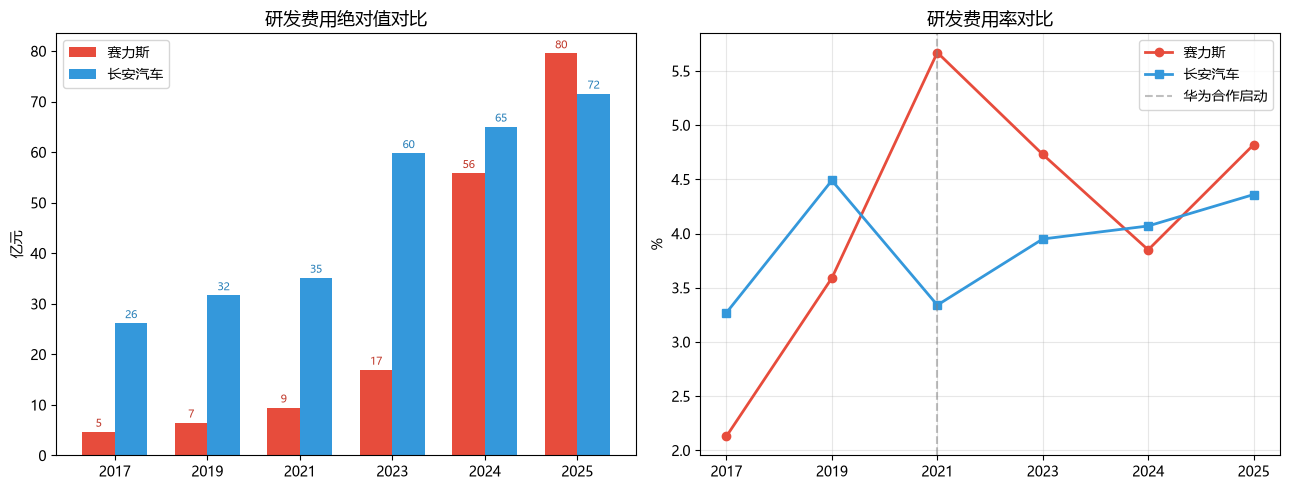


关键发现: 2024年起赛力斯研发投入暴增(55.86亿), 2025年研发率(4.82%)首超长安(4.36%)


In [17]:
import matplotlib.pyplot as plt
# ============ 研发投入对比（赛力斯 vs 长安） ============
rd_data = {
    '年份': ['2017', '2019', '2021', '2023', '2024', '2025'],
    '赛力斯_研发费用(亿)': [4.68, 6.51, 9.48, 16.96, 55.86, 79.54],
    '长安_研发费用(亿)':   [26.17, 31.69, 35.15, 59.80, 65.05, 71.58],
    '赛力斯_研发率(%)':    [2.13, 3.59, 5.67, 4.73, 3.85, 4.82],
    '长安_研发率(%)':      [3.27, 4.49, 3.34, 3.95, 4.07, 4.36],
}
df_rd = pd.DataFrame(rd_data).set_index('年份')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 左: 研发费用绝对值
x = range(len(df_rd))
w = 0.35
ax1.bar([i - w/2 for i in x], df_rd['赛力斯_研发费用(亿)'], w, color='#E74C3C', label='赛力斯')
ax1.bar([i + w/2 for i in x], df_rd['长安_研发费用(亿)'], w, color='#3498DB', label='长安汽车')
ax1.set_xticks(x); ax1.set_xticklabels(df_rd.index)
ax1.set_ylabel('亿元'); ax1.set_title('研发费用绝对值对比', fontsize=13)
ax1.legend()
for i, (sl, ca) in enumerate(zip(df_rd['赛力斯_研发费用(亿)'], df_rd['长安_研发费用(亿)'])):
    ax1.text(i - w/2, sl + 1, f'{sl:.0f}', ha='center', fontsize=8, color='#C0392B')
    ax1.text(i + w/2, ca + 1, f'{ca:.0f}', ha='center', fontsize=8, color='#2980B9')

# 右: 研发费用率
ax2.plot(df_rd.index, df_rd['赛力斯_研发率(%)'], 'o-', color='#E74C3C', linewidth=2, label='赛力斯')
ax2.plot(df_rd.index, df_rd['长安_研发率(%)'], 's-', color='#3498DB', linewidth=2, label='长安汽车')
ax2.axvline(x='2021', color='gray', linestyle='--', alpha=0.5, label='华为合作启动')
ax2.set_ylabel('%'); ax2.set_title('研发费用率对比', fontsize=13)
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print('\n关键发现: 2024年起赛力斯研发投入暴增(55.86亿), 2025年研发率(4.82%)首超长安(4.36%)')


##### 三、财务分析

1. K-Means 聚类分析（8家车企风险分群，K=2）

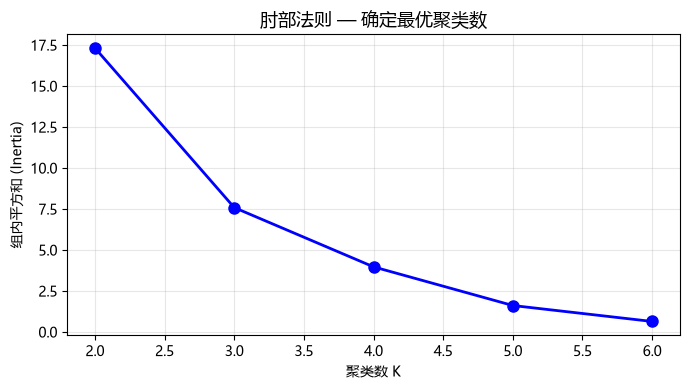

  K-Means 聚类结果 (K=3)

  群0 (3家): 长安汽车, 上汽集团, 广汽集团
    净资产收益率: 0.3%
    资产负债率: 57.0%
    流动比率: 1.18
    总资产周转率: 0.65
    营业收入增长率: 43.7%

  群1 (4家): 比亚迪, 江淮汽车, 赛力斯, 长城汽车
    净资产收益率: 8.9%
    资产负债率: 70.4%
    流动比率: 0.94
    总资产周转率: 1.08
    营业收入增长率: 54.0%

  群2 (1家): 北汽蓝谷
    净资产收益率: -332.2%
    资产负债率: 88.5%
    流动比率: 0.65
    总资产周转率: 0.84
    营业收入增长率: 184.6%

--- 综合风险评分（0=低风险, 1=高风险） ---
  🔴 北汽蓝谷  : 风险分=1.676 (高风险)
  🔴 江淮汽车  : 风险分=0.841 (高风险)
  🔴 广汽集团  : 风险分=0.747 (高风险)
  ⚠️ 比亚迪   : 风险分=0.717 (中风险)
  ⚠️ 上汽集团  : 风险分=0.690 (中风险)
  ✅ 长安汽车  : 风险分=0.655 (低风险)
  ✅ 长城汽车  : 风险分=0.624 (低风险)
  ✅ 赛力斯   : 风险分=0.583 (低风险)

  轮廓系数 (Silhouette): 0.310 （越接近1越好）
  Calinski-Harabasz 指数: 10.7 （越大越好）

--- 赛力斯 vs 长安 多维度雷达图 ---


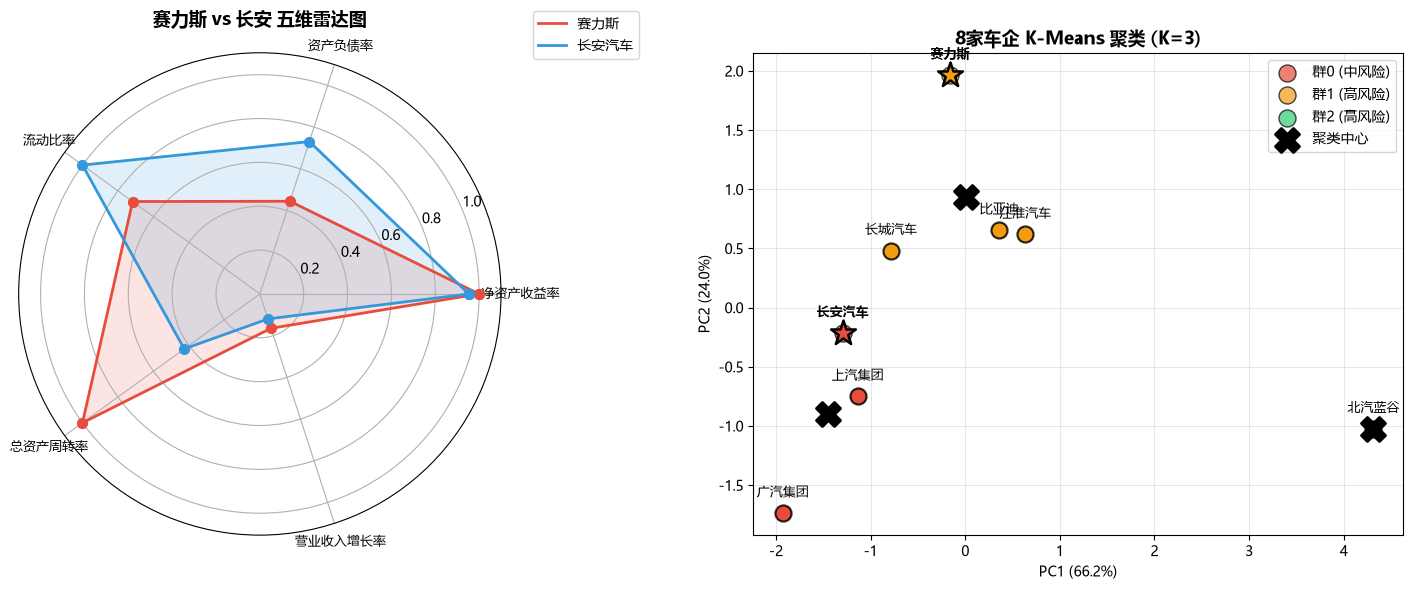


--- 赛力斯 vs 长安 核心差异 ---

  赛力斯: 群1 | 低风险 (分=0.583)
    净资产收益率: 21.9%
    资产负债率: 70.9%
    流动比率: 1.05
    总资产周转率: 1.40
    营业收入增长率: 54.8%

  长安汽车: 群0 | 低风险 (分=0.655)
    净资产收益率: 5.4%
    资产负债率: 59.6%
    流动比率: 1.21
    总资产周转率: 0.85
    营业收入增长率: 47.8%


In [18]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ============ 优化特征选择 ============
# 避免多重共线性（毛利率/净利润率高度相关）
# 覆盖盈利能力、偿债能力、营运能力、成长能力四个维度
FEATURES = [
    '净资产收益率',      # 盈利能力（综合ROE，替代毛利率+净利润率）
    '资产负债率',        # 长期偿债能力
    '流动比率',          # 短期偿债能力
    '总资产周转率',      # 营运能力（资产使用效率）
    '营业收入增长率'     # 成长能力
]

# ============ 数据准备 ============
records = []
for code, df_ratio in all_ratios.items():
    annual_idx = [i for i in df_ratio.index if '年报' in str(i)]
    if len(annual_idx) < 1:
        continue
    latest = annual_idx[-1]
    row = {'code': code, 'name': code.split('_')[1], 'period': latest}
    for f in FEATURES:
        row[f] = float(df_ratio.loc[latest, f]) if latest in df_ratio.index else None
    if all(row[f] is not None and not np.isnan(row[f]) for f in FEATURES):
        records.append(row)

df_kmeans = pd.DataFrame(records)
X = df_kmeans[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)

# ============ 肘部法则确定最优K ============
inertias = []
K_range = list(range(2, min(7, len(df_kmeans) + 1)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('聚类数 K'); ax.set_ylabel('组内平方和 (Inertia)')
ax.set_title('肘部法则 — 确定最优聚类数', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ============ K=3 聚类 ============
OPTIMAL_K = 3
km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_kmeans['cluster'] = km.fit_predict(X_scaled)

print('=' * 60)
print(f'  K-Means 聚类结果 (K={OPTIMAL_K})')
print('=' * 60)
for c in range(OPTIMAL_K):
    members = df_kmeans[df_kmeans['cluster'] == c]['name'].tolist()
    avg = df_kmeans[df_kmeans['cluster'] == c][FEATURES].mean()
    print(f'\n  群{c} ({len(members)}家): {", ".join(members)}')
    for f in FEATURES:
        if f in ['净资产收益率', '资产负债率', '营业收入增长率']:
            print(f'    {f}: {avg[f]*100:.1f}%')
        else:
            print(f'    {f}: {avg[f]:.2f}')

# ============ 综合风险评分 ============
print('\n--- 综合风险评分（0=低风险, 1=高风险） ---')
df_kmeans['risk_score'] = (
    (1 - df_kmeans['净资产收益率'].clip(upper=0.5)) * 0.25 +
    df_kmeans['资产负债率'] * 0.30 +
    (1 / df_kmeans['流动比率'].clip(lower=0.3)) * 0.20 +
    (1 - df_kmeans['总资产周转率'].clip(upper=3.0)) * 0.15 +
    (1 - df_kmeans['营业收入增长率'].clip(lower=-0.5, upper=1.0)) * 0.10
)
df_kmeans['risk_level'] = pd.qcut(df_kmeans['risk_score'], q=3,
                                   labels=['低风险', '中风险', '高风险'])
for _, row in df_kmeans.sort_values('risk_score', ascending=False).iterrows():
    icon = {'低风险': '✅', '中风险': '⚠️', '高风险': '🔴'}[row['risk_level']]
    print(f'  {icon} {row["name"]:<6s}: 风险分={row["risk_score"]:.3f} ({row["risk_level"]})')

# ============ 聚类效果评估 ============
sil = silhouette_score(X_scaled, df_kmeans['cluster'])
ch = calinski_harabasz_score(X_scaled, df_kmeans['cluster'])
print(f'\n  轮廓系数 (Silhouette): {sil:.3f} （越接近1越好）')
print(f'  Calinski-Harabasz 指数: {ch:.1f} （越大越好）')

# ============ 雷达图 + PCA 双图 ============
print('\n--- 赛力斯 vs 长安 多维度雷达图 ---')
radar_labels = FEATURES
targets = ['赛力斯', '长安汽车']

fig = plt.figure(figsize=(15, 6))

# 左：雷达图
ax_radar = fig.add_subplot(1, 2, 1, polar=True)
N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
colors_radar = ['#E74C3C', '#3498DB']

for idx, target in enumerate(targets):
    r = df_kmeans[df_kmeans['name'] == target]
    if len(r) == 0:
        continue
    values = []
    for f in radar_labels:
        v = r[f].values[0]
        max_v = df_kmeans[f].max()
        min_v = df_kmeans[f].min()
        if max_v == min_v:
            values.append(0.5)
        elif f == '资产负债率':
            values.append(1 - (v - min_v) / (max_v - min_v))  # 越低越好
        else:
            values.append((v - min_v) / (max_v - min_v))
    values += values[:1]
    ax_radar.fill(angles, values, color=colors_radar[idx], alpha=0.15)
    ax_radar.plot(angles, values, color=colors_radar[idx], linewidth=2, label=target)
    ax_radar.scatter(angles, values, color=colors_radar[idx], s=50, zorder=5)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=9)
ax_radar.set_title('赛力斯 vs 长安 五维雷达图', fontsize=13, fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar.set_ylim(0, 1.1)

# 右：PCA可视化
ax_pca = fig.add_subplot(1, 2, 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
colors = ['#E74C3C', '#F39C12', '#2ECC71'][:OPTIMAL_K]

for c in range(OPTIMAL_K):
    mask = df_kmeans['cluster'] == c
    avg_debt = df_kmeans[mask]['资产负债率'].mean()
    risk_label = '高风险' if avg_debt > 0.7 else ('中风险' if avg_debt > 0.55 else '低风险')
    ax_pca.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c], s=150,
                   label=f'群{c} ({risk_label})', edgecolors='black', alpha=0.7)

# 重绘每个点（标注+突出核心标的）
for i, row in df_kmeans.iterrows():
    is_core = row['name'] in ['赛力斯', '长安汽车']
    marker = '*' if is_core else 'o'
    size = 350 if is_core else 120
    ax_pca.scatter(X_pca[i, 0], X_pca[i, 1], c=colors[row['cluster']],
                   s=size, marker=marker, edgecolors='black',
                   linewidths=1.8 if is_core else 0.8, zorder=10 if is_core else 5)
    ax_pca.annotate(row['name'], (X_pca[i, 0], X_pca[i, 1]), fontsize=9,
                    ha='center', xytext=(0, 12), textcoords='offset points',
                    fontweight='bold' if is_core else 'normal')

centers_pca = pca.transform(km.cluster_centers_)
ax_pca.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X',
               s=300, label='聚类中心', zorder=15, linewidths=2)
ax_pca.set_title(f'8家车企 K-Means 聚类 (K={OPTIMAL_K})', fontsize=13, fontweight='bold')
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax_pca.legend(loc='best')
ax_pca.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 赛力斯 vs 长安 核心差异汇总 ============
print('\n--- 赛力斯 vs 长安 核心差异 ---')
for target in ['赛力斯', '长安汽车']:
    r = df_kmeans[df_kmeans['name'] == target]
    if len(r) == 0:
        continue
    r = r.iloc[0]
    print(f'\n  {target}: 群{r["cluster"]} | {r["risk_level"]} (分={r["risk_score"]:.3f})')
    for f in FEATURES:
        val = r[f]
        if f in ['净资产收益率', '资产负债率', '营业收入增长率']:
            print(f'    {f}: {val*100:.1f}%')
        else:
            print(f'    {f}: {val:.2f}')


2. 孤立森林异常检测

  孤立森林 异常检测
  长安汽车  :  正常 (得分=0.127)
  比亚迪   :  正常 (得分=0.097)
  上汽集团  :  正常 (得分=0.115)
  江淮汽车  :  正常 (得分=0.059)
  北汽蓝谷  : ⚠️ 异常 (得分=-0.140)
  赛力斯   :  正常 (得分=0.077)
  广汽集团  : ⚠️ 异常 (得分=-0.003)
  长城汽车  :  正常 (得分=0.136)

异常企业: ['北汽蓝谷', '广汽集团']


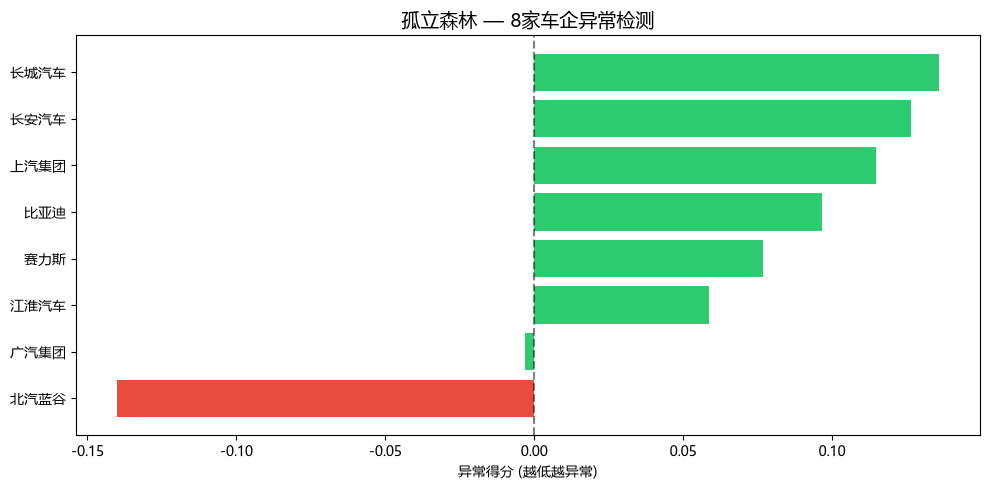

In [19]:
from sklearn.ensemble import IsolationForest

# ============ 孤立森林 ============
iso = IsolationForest(contamination=0.15, random_state=42)
anomaly_labels = iso.fit_predict(X_scaled)
anomaly_scores = iso.decision_function(X_scaled)

df_kmeans['anomaly'] = anomaly_labels
df_kmeans['anomaly_score'] = anomaly_scores

print('='*60)
print('  孤立森林 异常检测')
print('='*60)
for _, row in df_kmeans.iterrows():
    flag = '⚠️ 异常' if row['anomaly'] == -1 else ' 正常'
    print(f'  {row["name"]:<6s}: {flag} (得分={row["anomaly_score"]:.3f})')

print(f'\n异常企业: {df_kmeans[df_kmeans["anomaly"]==-1]["name"].tolist()}')

# ============ 可视化 ============
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = df_kmeans.sort_values('anomaly_score')
colors = ['#E74C3C' if s < -0.05 else '#2ECC71' for s in sorted_df['anomaly_score']]
ax.barh(range(len(sorted_df)), sorted_df['anomaly_score'], color=colors)
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_df['name'].values)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('异常得分 (越低越异常)')
ax.set_title('孤立森林 — 8家车企异常检测', fontsize=14)
plt.tight_layout()
plt.show()


3. Prophet 时序预测（赛力斯 vs 长安）

（1）LinearRegression模型，多项式拟合

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

def prophet_forecast(code, metric_col, forecast_quarters=4):
    """
    趋势预测（替代 Prophet）
    用全部季度数据拟合线性趋势 + 残差波动带 → 预测未来 N 个季度
    """
    df_ratio = all_ratios[code]
    name = code.split('_')[1]

    # ---- 准备数据 ----
    series = df_ratio[metric_col].replace(0, np.nan).dropna()
    if len(series) < 8:
        print(f'  {name} {metric_col}: 有效数据不足 ({len(series)})')
        return

    y = series.values
    n = len(y)
    x_idx = np.arange(n).reshape(-1, 1)

    # ---- 趋势拟合 ----
    lr = LinearRegression().fit(x_idx, y)
    trend_line = lr.predict(x_idx)                     # 历史拟合线
    residuals = y - trend_line                          # 残差
    sigma = np.std(residuals)                           # 残差标准差（波动带宽度）

    # ---- 预测 ----
    future_x = np.arange(n, n + forecast_quarters).reshape(-1, 1)
    pred = lr.predict(future_x)
    upper = pred + 2 * sigma                            # 上界（95% CI）
    lower = pred - 2 * sigma                            # 下界

    direction = '↑上升' if lr.coef_[0] > 0 else '↓下降'
    change_pct = (pred[-1] - y[-1]) / abs(y[-1]) * 100 if y[-1] != 0 else 0

    # ---- 图表 ----
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(n), y, 'k.', markersize=5, label=f'实际 ({n}期)')
    ax.plot(range(n), trend_line, 'b-', linewidth=1.5, alpha=0.5, label='趋势线')
    ax.plot(range(n, n + forecast_quarters), pred, 'r^--', markersize=8,
            label=f'预测 {forecast_quarters}Q [{direction}]')
    ax.fill_between(range(n, n + forecast_quarters), lower, upper,
                     color='r', alpha=0.12, label='±2σ 波动带')
    ax.set_title(f'{name} — {metric_col} 趋势预测 [{direction}] ({forecast_quarters*3}个月)', fontsize=13)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 输出 ----
    print(f'  {name} {metric_col}: {direction}')
    print(f'    当前: {y[-1]:.4f}  →  预测{forecast_quarters}Q后: {pred[-1]:.4f}')
    print(f'    变动: {change_pct:+.1f}%')
    print(f'    趋势斜率(每期): {lr.coef_[0]:.4f},  波动带(±2σ): [{lower[-1]:.4f}, {upper[-1]:.4f}]')


# ============ 运行 ============
METRICS = ['毛利率', '净利润率', '净资产收益率', '资产负债率']
FORECAST_Q = 4   # 2=6个月, 4=12个月

for code in ['601127_赛力斯', '000625_长安汽车']:
    if code not in all_ratios:
        continue
    print(f'\n{"="*50}')
    print(f'  {code.split("_")[1]}（未来 {FORECAST_Q*3} 个月预测）')
    print(f'{"="*50}')
    for metric in METRICS:
        prophet_forecast(code, metric, forecast_quarters=FORECAST_Q)


（2）Prophet 时序预测


  赛力斯（未来 12 个月预测）


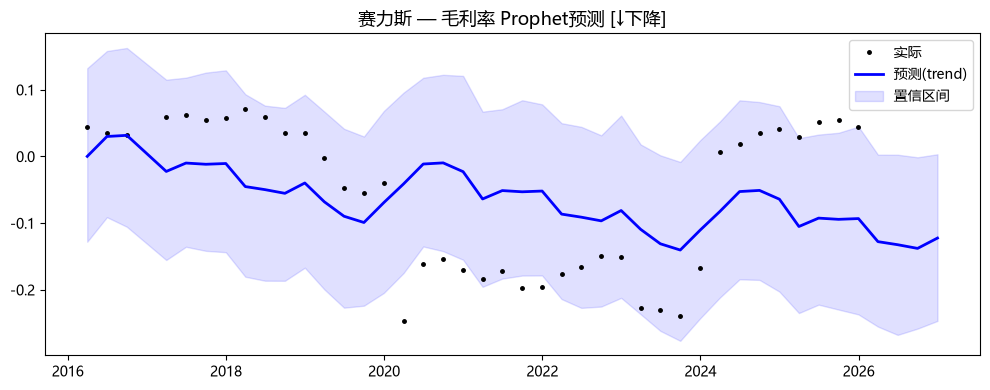

  赛力斯 毛利率: ↓下降
    当前: 0.0550  →  预测4Q后: -0.1223
    变动: -322.3%


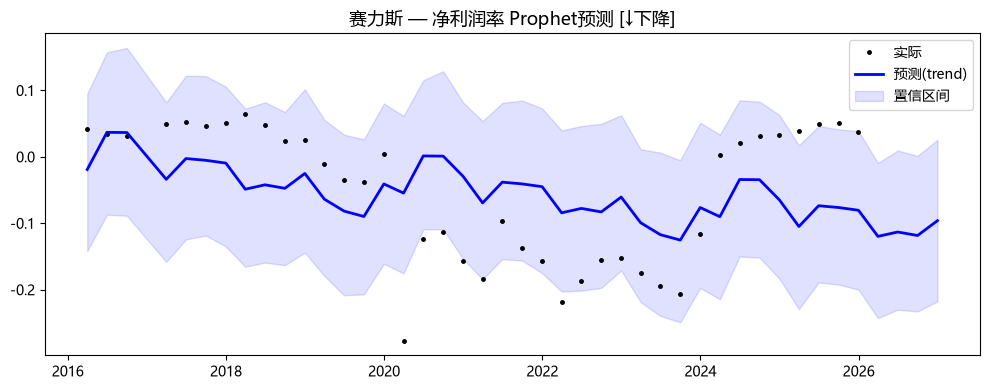

  赛力斯 净利润率: ↓下降
    当前: 0.0510  →  预测4Q后: -0.0961
    变动: -288.5%


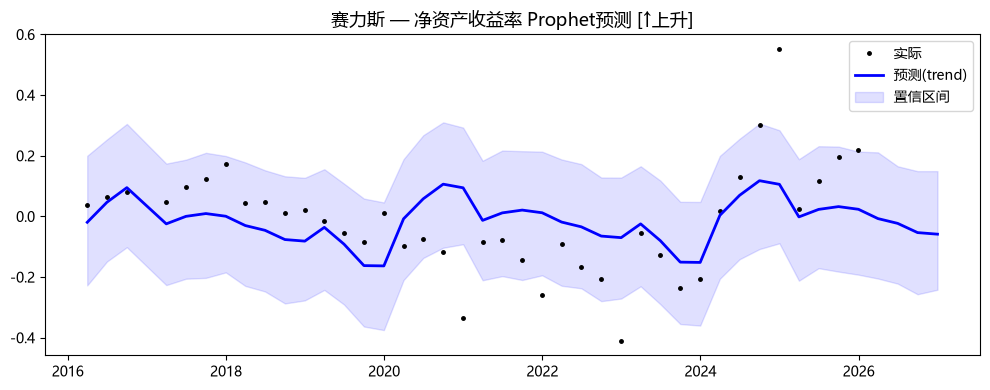

  赛力斯 净资产收益率: ↑上升
    当前: 0.1947  →  预测4Q后: -0.0587
    变动: -130.1%


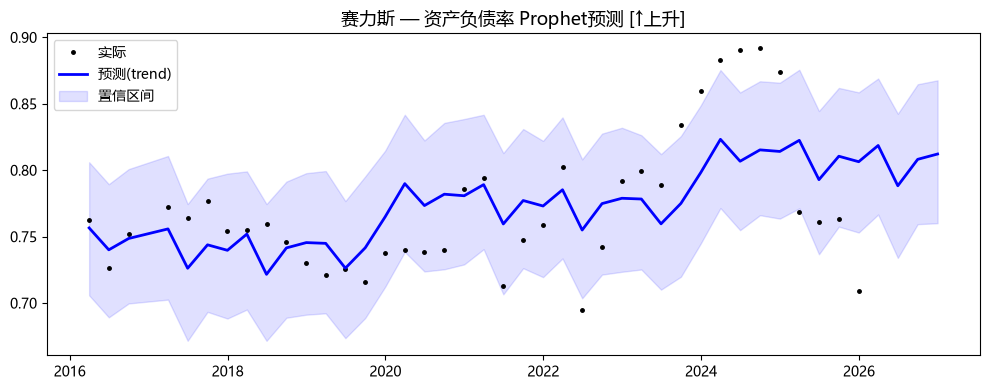

  赛力斯 资产负债率: ↑上升
    当前: 0.7636  →  预测4Q后: 0.8121
    变动: +6.4%

  长安汽车（未来 12 个月预测）


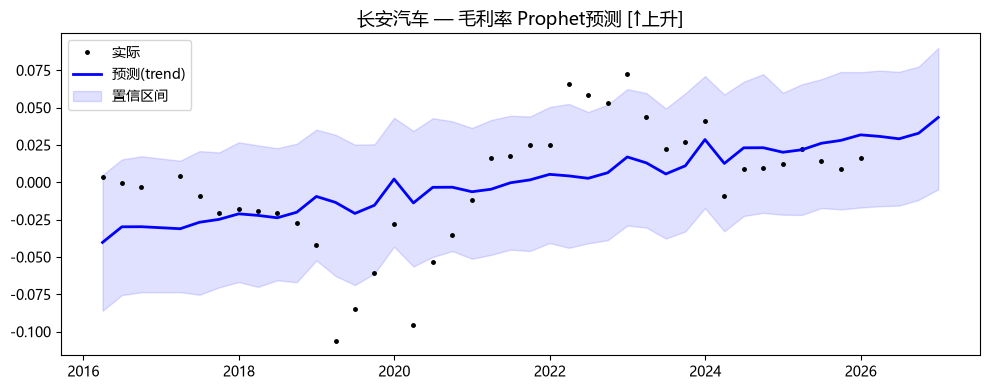

  长安汽车 毛利率: ↑上升
    当前: 0.0088  →  预测4Q后: 0.0434
    变动: +394.0%


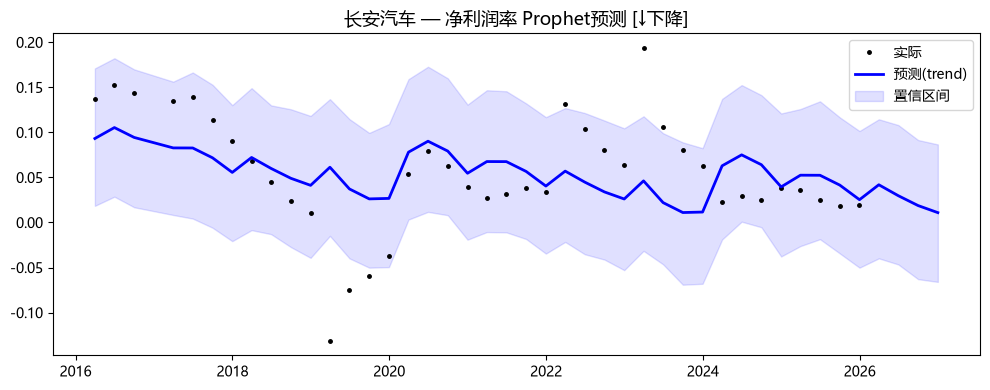

  长安汽车 净利润率: ↓下降
    当前: 0.0187  →  预测4Q后: 0.0109
    变动: -41.5%


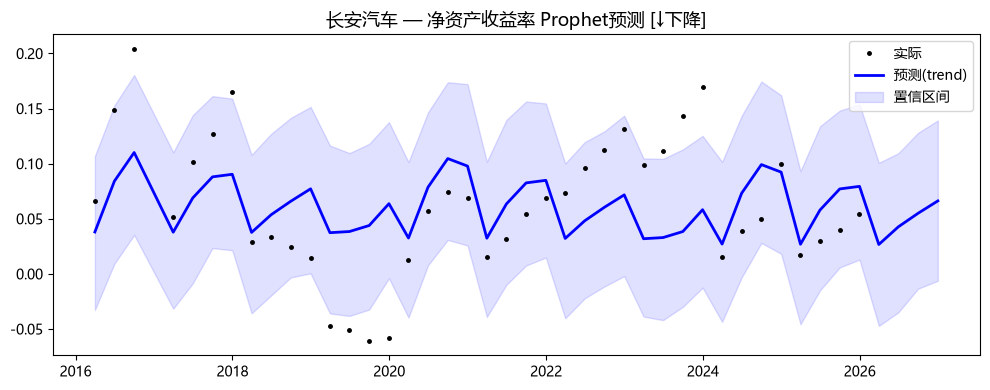

  长安汽车 净资产收益率: ↓下降
    当前: 0.0399  →  预测4Q后: 0.0662
    变动: +65.9%


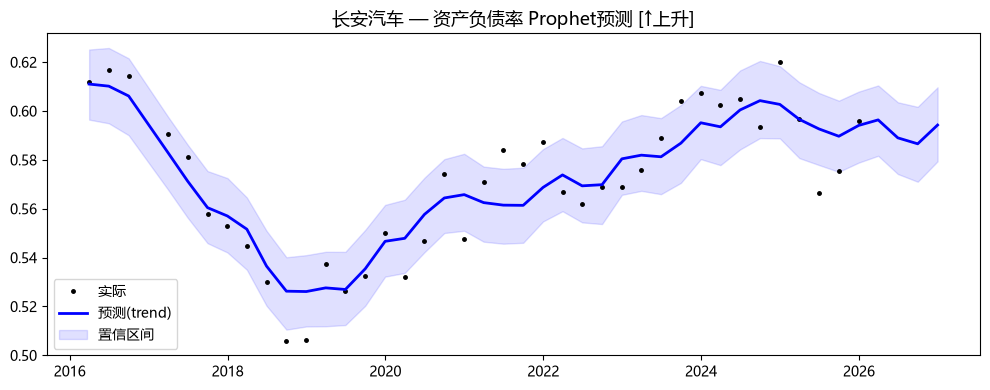

  长安汽车 资产负债率: ↑上升
    当前: 0.5755  →  预测4Q后: 0.5943
    变动: +3.3%


In [20]:
import os, tempfile, shutil

CLEAN_DIR = os.path.join(tempfile.gettempdir(), 'prophet_work')
os.makedirs(CLEAN_DIR, exist_ok=True)
os.environ['TMPDIR'] = CLEAN_DIR
os.environ['TEMP'] = CLEAN_DIR
os.environ['TMP'] = CLEAN_DIR
_orig_cwd = os.getcwd()
os.chdir(CLEAN_DIR)

from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

def prophet_forecast(code, metric_col, forecast_quarters=4):
    """
    Prophet 时序预测：未来 6-12 个月
    """
    df_ratio = all_ratios[code]
    name = code.split('_')[1]

    # ---- 准备数据 ----
    df_p = df_ratio[[metric_col]].reset_index()
    df_p['ds'] = pd.to_datetime(
        df_p['index'].str.replace('年报', '-12-31')
                     .str.replace('Q1', '-03-31')
                     .str.replace('Q2', '-06-30')
                     .str.replace('Q3', '-09-30'),
        errors='coerce')
    df_p = df_p.rename(columns={metric_col: 'y'}).dropna(subset=['ds', 'y'])
    df_p = df_p[df_p['y'] != 0].copy()

    if len(df_p) < 10:
        print(f'  {name} {metric_col}: 有效数据不足 ({len(df_p)})')
        return

    # ---- Prophet ----
    m = Prophet(growth='linear',
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='additive')
    m.fit(df_p[['ds', 'y']])

    future = m.make_future_dataframe(periods=forecast_quarters, freq='QE')
    forecast = m.predict(future)

    # 趋势方向
    hist_end = forecast[forecast['ds'] <= df_p['ds'].max()]['trend'].iloc[-1]
    pred_end = forecast['trend'].iloc[-1]
    direction = '↑上升' if pred_end > hist_end else '↓下降'
    change_pct = (forecast['yhat'].iloc[-1] - df_p['y'].iloc[-1]) \
                 / abs(df_p['y'].iloc[-1]) * 100

    # 图表
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df_p['ds'], df_p['y'], 'k.', markersize=5, label='实际')
    ax.plot(forecast['ds'], forecast['yhat'], 'b-', linewidth=2, label='预测(trend)')
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     color='b', alpha=0.12, label='置信区间')
    ax.set_title(f'{name} — {metric_col} Prophet预测 [{direction}]', fontsize=13)
    ax.legend(); plt.tight_layout(); plt.show()

    print(f'  {name} {metric_col}: {direction}')
    print(f'    当前: {df_p["y"].iloc[-1]:.4f}  →  '
          f'预测{forecast_quarters}Q后: {forecast["yhat"].iloc[-1]:.4f}')
    print(f'    变动: {change_pct:+.1f}%')


# ============ 运行 ============
METRICS = ['毛利率', '净利润率', '净资产收益率', '资产负债率']
FORECAST_Q = 4

for code in ['601127_赛力斯', '000625_长安汽车']:
    if code not in all_ratios:
        continue
    print(f'\n{"="*50}')
    print(f'  {code.split("_")[1]}（未来 {FORECAST_Q*3} 个月预测）')
    print(f'{"="*50}')
    for metric in METRICS:
        prophet_forecast(code, metric, forecast_quarters=FORECAST_Q)

# 恢复原始工作目录
os.chdir(_orig_cwd)


Prophet 预测出极端值（毛利率变负）很可疑：仅有 ~20 个有效数据点，且 yearly_seasonality=True 对小样本极易过拟合；

用 Prophet 做趋势方向判断而非精确数值预测

##### 四、综合评价
1. 杜邦分析 ROE 分解

In [21]:
# ============ 杜邦分析：ROE = 净利率 × 总资产周转率 × 权益乘数 ============
def dupont_decompose(code, name):
    fp = f'data/{code}_财务数据.xlsx'
    xl = pd.ExcelFile(fp)
    df_is = pd.read_excel(xl, '利润表', index_col=0)
    df_bs = pd.read_excel(xl, '资产负债表', index_col=0)

    annual = [c for c in df_is.columns if '年报' in str(c)]
    if len(annual) < 2: return

    # 取最新两年
    prev, curr = annual[-2], annual[-1]

    def get(df, item, col):
        return float(df.loc[item, col]) if item in df.index and col in df.columns else None

    npm_prev = get(df_is, '净利润', prev) / get(df_is, '营业收入', prev)
    npm_curr = get(df_is, '净利润', curr) / get(df_is, '营业收入', curr)
    tat_prev = get(df_is, '营业收入', prev) / get(df_bs, '资产合计', prev)
    tat_curr = get(df_is, '营业收入', curr) / get(df_bs, '资产合计', curr)
    em_prev  = get(df_bs, '资产合计', prev) / get(df_bs, '归属于母公司所有者权益合计', prev)
    em_curr  = get(df_bs, '资产合计', curr) / get(df_bs, '归属于母公司所有者权益合计', curr)

    roe_prev = npm_prev * tat_prev * em_prev
    roe_curr = npm_curr * tat_curr * em_curr

    # 连环替代法
    r0 = npm_prev * tat_prev * em_prev
    r1 = npm_curr * tat_prev * em_prev
    r2 = npm_curr * tat_curr * em_prev
    r3 = npm_curr * tat_curr * em_curr

    return {
        'period': f'{prev}→{curr}',
        'ROE': (roe_prev, roe_curr, roe_curr - roe_prev),
        '净利率': (npm_prev, npm_curr, r1 - r0),
        '总资产周转率': (tat_prev, tat_curr, r2 - r1),
        '权益乘数': (em_prev, em_curr, r3 - r2),
    }

print('=' * 60)
print('  杜邦分析 — ROE 因素分解（连环替代法）')
print('=' * 60)
for code in ['601127_赛力斯', '000625_长安汽车']:
    name = code.split('_')[1]
    r = dupont_decompose(code, name)
    if r is None: continue
    print(f'\n  {name} [{r["period"]}]')
    print(f'    ROE:        {r["ROE"][0]*100:.1f}% → {r["ROE"][1]*100:.1f}%  (变动: {r["ROE"][2]*100:+.1f}pp)')
    print(f'    净利率贡献:  {r["净利率"][2]*100:+.1f}pp  ({r["净利率"][0]*100:.1f}%→{r["净利率"][1]*100:.1f}%)')
    print(f'    周转率贡献:  {r["总资产周转率"][2]*100:+.1f}pp  ({r["总资产周转率"][0]:.2f}→{r["总资产周转率"][1]:.2f})')
    print(f'    杠杆贡献:    {r["权益乘数"][2]*100:+.1f}pp  ({r["权益乘数"][0]:.2f}→{r["权益乘数"][1]:.2f})')


  杜邦分析 — ROE 因素分解（连环替代法）

  赛力斯 [2024年报→2025年报]
    ROE:        38.7% → 15.0%  (变动: -23.6pp)
    净利率贡献:  +5.4pp  (3.3%→3.7%)
    周转率贡献:  -11.2pp  (1.54→1.15)
    杠杆贡献:    -17.8pp  (7.69→3.52)

  长安汽车 [2024年报→2025年报]
    ROE:        8.0% → 4.1%  (变动: -3.9pp)
    净利率贡献:  -3.9pp  (3.8%→1.9%)
    周转率贡献:  +0.2pp  (0.77→0.81)
    杠杆贡献:    -0.1pp  (2.72→2.62)


2. Altman Z-score 破产预警 + 沃尔评分排名（(统一权重)）

In [22]:
zscore_data = {}
wolle_data = {}

for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    name = code.split('_')[1]
    xl = pd.ExcelFile(fp)
    
    if '财务分析指标' not in xl.sheet_names:
        continue
    
    df_d = pd.read_excel(xl, '财务分析指标', index_col=0)  # index=报告期
    # FIX: 找 index 中含 "年报" 的行（不是 columns！）
    annual_rows = [i for i in df_d.index if '年报' in str(i)]
    if not annual_rows:
        continue
    latest = annual_rows[-1]  # 最新年报是哪一行
    
    # Z-score（注意：df_d.loc[报告期, 列名]）
    if 'Altman Z-score' in df_d.columns:
        z = float(df_d.loc[latest, 'Altman Z-score'])
        status = '安全区' if z > 2.99 else ('灰色区' if z >= 1.81 else '危险区')
        zscore_data[name] = {'Z-score': z, '判定': status}
    
    # 沃尔评分
    criteria = {
    'ROE(%)':                (25, 10, 'higher'),   # 盈利能力（最高权重）
    '净利率(%)':             (20, 8,  'higher'),
    '总资产周转率(次)':      (15, 1.5, 'higher'),  # 营运能力
    '资产负债率(%)':         (10, 50,  'center'),  # 偿债能力
    '流动比率':              (10, 2,   'center'),
    '营收同比(%)':           (10, 10,  'higher'),  # 成长能力
    '毛利率(%)':             (5,  20,  'higher'),
    '经营现金流/净利润':     (5,  1,   'center'),
   }
    total = 0
    total_w = sum(w for w, _, _ in criteria.values())
    for metric, (weight, std, direction) in criteria.items():
        if metric in df_d.columns:  # FIX: 检查 columns
            val = float(df_d.loc[latest, metric])  # FIX: loc[行, 列]
            if pd.isna(val):
                continue
            if direction == 'higher':
                ratio = val / std if std else 0
            elif direction == 'lower':
                ratio = std / val if val else 0
            else:
                ratio = 1 - abs(val - std) / max(std, abs(val), 1)
            ratio = max(0, min(2, ratio))
            total += ratio * 100 * weight / total_w
    wolle_data[name] = total

# ============ 输出 ============
print('='*60)
print('  Altman Z-score 破产预警')
print('='*60)
for name in sorted(zscore_data):
    d = zscore_data[name]
    icon = '' if d['判定'] == '安全区' else ('⚠️' if d['判定'] == '灰色区' else '🔴')
    print(f'  {icon} {name:<6s}: Z={d["Z-score"]:.2f} ({d["判定"]})')

print('\n' + '='*60)
print('  沃尔评分 — 综合排名')
print('='*60)
ranking = sorted(wolle_data.items(), key=lambda x: x[1], reverse=True)
for rank, (name, score) in enumerate(ranking, 1):
    medal = '🥇' if rank == 1 else ('🥈' if rank == 2 else ('🥉' if rank == 3 else f'  {rank}'))
    print(f'  {medal}. {name:<6s}: {score:.1f} 分')


  Altman Z-score 破产预警
  🔴 上汽集团  : Z=1.57 (危险区)
  🔴 北汽蓝谷  : Z=-1.44 (危险区)
  🔴 广汽集团  : Z=1.32 (危险区)
  🔴 比亚迪   : Z=1.38 (危险区)
  🔴 江淮汽车  : Z=0.84 (危险区)
  🔴 赛力斯   : Z=1.63 (危险区)
  ⚠️ 长城汽车  : Z=2.08 (灰色区)
  ⚠️ 长安汽车  : Z=1.82 (灰色区)

  沃尔评分 — 综合排名
  🥇. 赛力斯   : 101.3 分
  🥈. 长城汽车  : 76.6 分
  🥉. 比亚迪   : 75.2 分
    4. 上汽集团  : 47.6 分
    5. 长安汽车  : 43.1 分
    6. 北汽蓝谷  : 36.4 分
    7. 江淮汽车  : 30.0 分
    8. 广汽集团  : 23.6 分


3. 销量结构对比：赛力斯 vs 长安

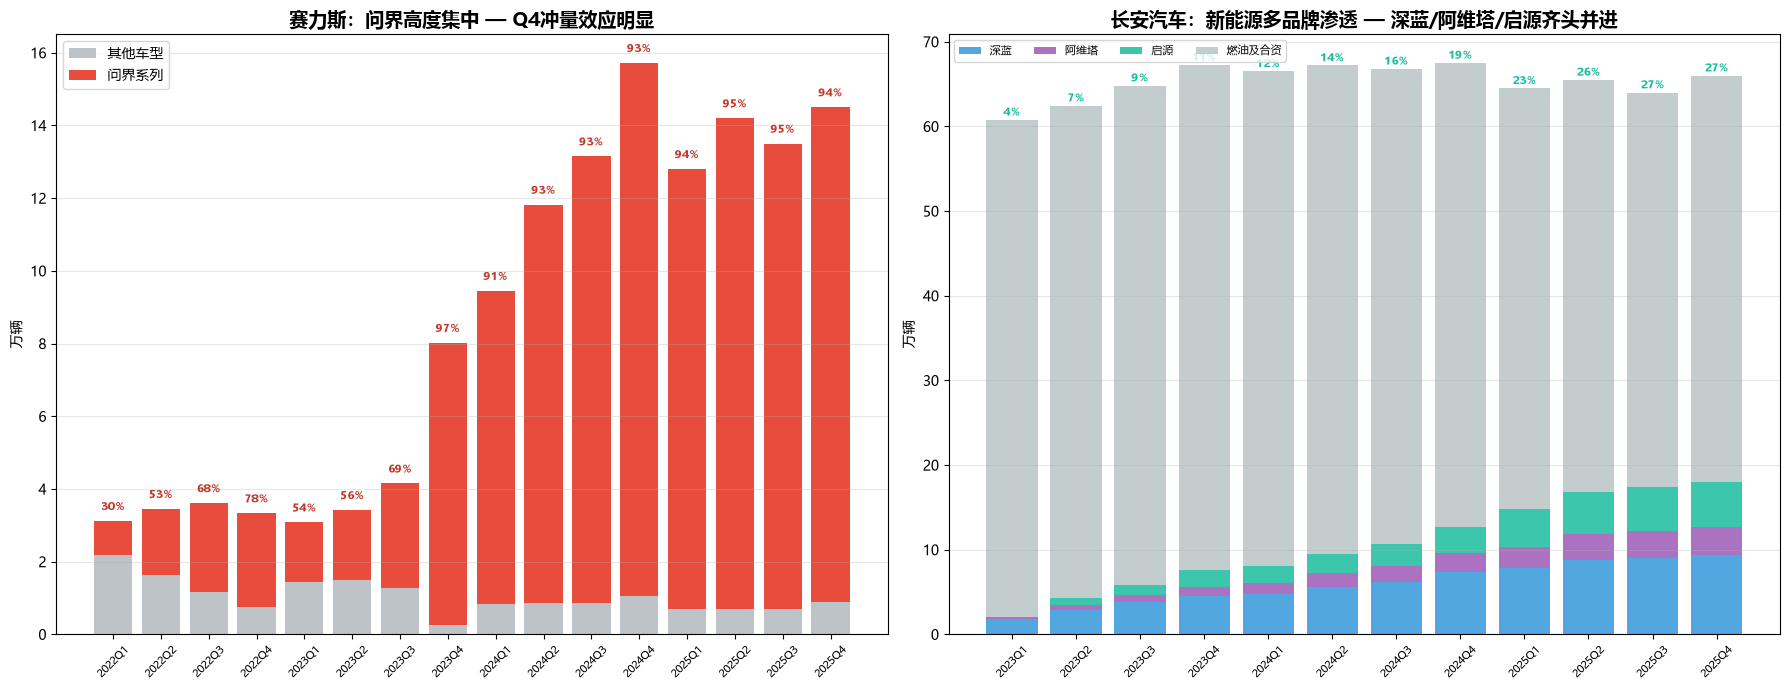


结论: 赛力斯Q4冲量效应显著, 问界占比从30%飙升至95%, 集中风险持续恶化
      长安新能源从3.5%稳步升至27%, 深蓝/阿维塔/启源三品牌抵御单一品牌风险能力更强


In [23]:
# ============ 销量结构对比（季度粒度，观察季节性波动） ============
df_sl = pd.read_excel('data/赛力斯_季度销量结构.xlsx')
df_ca = pd.read_excel('data/长安汽车_季度销量结构.xlsx')

# ---- 赛力斯：季度堆叠柱状图（问界 vs 其他） ----
x_sl = range(len(df_sl))
labels_sl = df_sl['时期'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))  # 改为左右布局，宽度增加

# 赛力斯 问界 vs 其他
ax1.bar(x_sl, df_sl['其他车型(万辆)'], color='#BDC3C7', label='其他车型')
ax1.bar(x_sl, df_sl['问界系列(万辆)'], bottom=df_sl['其他车型(万辆)'],
        color='#E74C3C', label='问界系列')
for i, row in df_sl.iterrows():
    ax1.text(i, row['总销量(万辆)'] + 0.3, f"{row['问界占比(%)']:.0f}%",
             ha='center', fontsize=8, fontweight='bold', color='#C0392B')
ax1.set_xticks(x_sl); ax1.set_xticklabels(labels_sl, rotation=45, fontsize=8)
ax1.set_ylabel('万辆'); ax1.set_title('赛力斯：问界高度集中 — Q4冲量效应明显', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# 长安 深蓝/阿维塔/启源 vs 燃油合资
x_ca = range(len(df_ca))
labels_ca = df_ca['时期'].tolist()
bottom = np.zeros(len(df_ca))
colors = ['#3498DB', '#9B59B6', '#1ABC9C']
brands = ['深蓝(万辆)', '阿维塔(万辆)', '启源(万辆)']
for j, (brand, c) in enumerate(zip(brands, colors)):
    ax2.bar(x_ca, df_ca[brand], bottom=bottom, color=c, alpha=0.85, label=brand.replace('(万辆)', ''))
    bottom += df_ca[brand].values
ax2.bar(x_ca, df_ca['燃油及合资(万辆)'], bottom=bottom, color='#95A5A6', alpha=0.55, label='燃油及合资')
for i, row in df_ca.iterrows():
    ax2.text(i, row['总销量(万辆)'] + 0.5, f"{row['新能源占比(%)']:.0f}%",
             ha='center', fontsize=8, fontweight='bold', color='#1ABC9C')
ax2.set_xticks(x_ca); ax2.set_xticklabels(labels_ca, rotation=45, fontsize=8)
ax2.set_ylabel('万辆'); ax2.set_title('长安汽车：新能源多品牌渗透 — 深蓝/阿维塔/启源齐头并进', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', ncol=4, fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n结论: 赛力斯Q4冲量效应显著, 问界占比从30%飙升至95%, 集中风险持续恶化')
print('      长安新能源从3.5%稳步升至27%, 深蓝/阿维塔/启源三品牌抵御单一品牌风险能力更强')


##### 五、结论与对策建议：

`综合结论 + 风险雷达图 + 差异化建议`

1. 差异化对策建议：

* 赛力斯：降低问界单一系列依赖，拓展非华为渠道；控制杠杆率，Z-score 已入危险区
* 长安汽车：加快新能源渗透率提升（当前仅 27%），深蓝/阿维塔/启源需加速放量

*研究局限：样本仅 8 家 A 股车企，Prophet 预测受小样本限制，结论需结合行业定性分析*